# Figure 4: Decision-Variable Receptive Fields

Estimate receptive fields of the saved edge and bump neurons over the decision variable. The DV is the model readout , already in ; no  transform is applied.

This notebook computes RFs directly from  and keeps the results in notebook variables.


In [2]:
from __future__ import annotations
%config InlineBackend.figure_format = 'retina'

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

REPO_ROOT = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from rate_model_core.config import NeuralGeometryConfig, build_geometry


# DATA_PATH = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure4/fig4_edge_bump_dynamics_1000trials/single_condition_dynamics.npz')
#DATA_PATH = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure4/dv_receptive_fields/single_condition_dynamics.npz')
DATA_PATH = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure4/dv_receptive_fields_wo_noise/single_condition_dynamics.npz')

NUM_BINS = 100
MIN_OCCUPANCY = 20

plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


Matplotlib is building the font cache; this may take a moment.


## Load Data

The saved dynamics dataset contains 100 trials, full , and selected neurons  for both edge and bump populations.


In [3]:
with np.load(DATA_PATH, allow_pickle=False) as data:
    metadata = json.loads(str(data['metadata_json'].item()))
    x_E = np.asarray(data['x_E'], dtype=float)
    r_E = np.asarray(data['r_E'], dtype=float)
    r_B = np.asarray(data['r_B'], dtype=float)
    time_ms = np.asarray(data['time_ms'], dtype=float)
    rt_ms = np.asarray(data['rt_ms'], dtype=float)
    hit_boundary = np.asarray(data['hit_boundary'], dtype=bool)
    choice = np.asarray(data['choice'], dtype=int)

selected_neuron_indices = np.asarray(metadata['selected_neuron_indices'], dtype=int)
t_start = float(metadata['t_start'])

print('x_E shape:', x_E.shape)
print('r_E shape:', r_E.shape)
print('r_B shape:', r_B.shape)
print('x_E range:', float(np.nanmin(x_E)), float(np.nanmax(x_E)))
print('t_start:', t_start)
print('selected neuron range:', int(selected_neuron_indices[0]), int(selected_neuron_indices[-1]))

assert x_E.shape == r_E.shape[:2] == r_B.shape[:2]
assert r_E.shape[2] == r_B.shape[2] == selected_neuron_indices.size
assert np.nanmin(x_E) >= -1e-6
assert np.nanmax(x_E) <= 1 + 1e-6


x_E shape: (1000, 2000)
r_E shape: (1000, 2000, 120)
r_B shape: (1000, 2000, 120)
x_E range: 0.009895144030451775 0.9902451634407043
t_start: 10.0
selected neuron range: 452 571


## Compute RFs

We bin  from  to . Samples are restricted to the decision period and exclude post-boundary samples for hit trials.


In [4]:
def make_predecision_mask(x_e, time_ms, hit_boundary, rt_ms, t_start):
    valid = np.isfinite(x_e)
    valid &= time_ms[None, :] >= float(t_start)
    for trial_idx in range(x_e.shape[0]):
        if bool(hit_boundary[trial_idx]) and np.isfinite(float(rt_ms[trial_idx])):
            valid[trial_idx] &= time_ms <= float(t_start) + float(rt_ms[trial_idx])
    return valid


def bin_mean(values, bin_index, occupancy, num_bins, min_occupancy):
    sums = np.bincount(bin_index, weights=values, minlength=num_bins).astype(float)
    means = np.full(num_bins, np.nan, dtype=float)
    np.divide(sums, occupancy, out=means, where=occupancy > 0)
    means[occupancy < int(min_occupancy)] = np.nan
    return means


def estimate_rf(rates, valid_mask, bin_index, keep, occupancy, num_bins, min_occupancy):
    rf = np.full((rates.shape[2], num_bins), np.nan, dtype=float)
    for neuron_idx in range(rates.shape[2]):
        values = rates[:, :, neuron_idx][valid_mask][keep]
        rf[neuron_idx] = bin_mean(values, bin_index, occupancy, num_bins, min_occupancy)
    return rf

bin_edges = np.linspace(0.0, 1.0, NUM_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
valid_mask = make_predecision_mask(x_E, time_ms, hit_boundary, rt_ms, t_start)

dv_flat = x_E[valid_mask]
raw_bin_index = np.digitize(dv_flat, bin_edges, right=False) - 1
raw_bin_index[dv_flat == bin_edges[-1]] = NUM_BINS - 1
keep = (raw_bin_index >= 0) & (raw_bin_index < NUM_BINS)
bin_index = raw_bin_index[keep]
occupancy = np.bincount(bin_index, minlength=NUM_BINS).astype(int)

RF_E = estimate_rf(r_E, valid_mask, bin_index, keep, occupancy, NUM_BINS, MIN_OCCUPANCY)
RF_B = estimate_rf(r_B, valid_mask, bin_index, keep, occupancy, NUM_BINS, MIN_OCCUPANCY)

print('valid samples:', int(valid_mask.sum()))
print('in-range samples:', int(keep.sum()))
print('reliable bins:', int(np.sum(occupancy >= MIN_OCCUPANCY)), '/', NUM_BINS)
print('RF_E shape:', RF_E.shape)
print('RF_B shape:', RF_B.shape)


valid samples: 1442750
in-range samples: 1442750
reliable bins: 100 / 100
RF_E shape: (120, 100)
RF_B shape: (120, 100)


## Occupancy Diagnostic


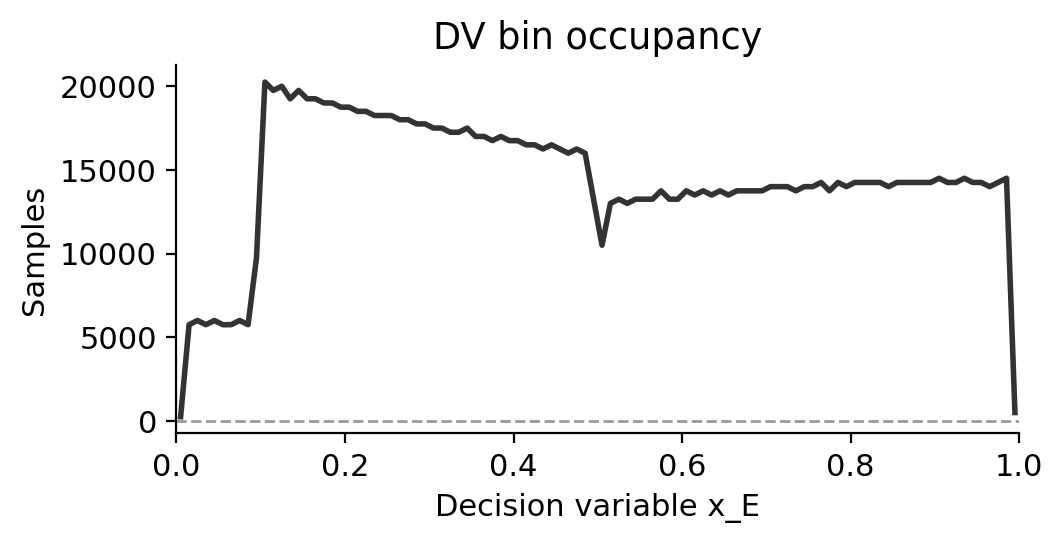

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 2.6), constrained_layout=True)
ax.plot(bin_centers, occupancy, color='0.2', linewidth=2.0)
ax.axhline(MIN_OCCUPANCY, color='0.6', linestyle='--', linewidth=1.0)
ax.set_xlabel('Decision variable x_E')
ax.set_ylabel('Samples')
ax.set_xlim(0, 1)
ax.set_title('DV bin occupancy')
plt.show()


## RF Heatmaps


In [26]:
SAVE_DIR = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

EDGE_COLOR = '#1d52a1'
BUMP_COLOR = '#716db2'
BLUE_GREEN_YELLOW_CMAP = LinearSegmentedColormap.from_list(
    'BlueGreenYellow',
    ['#1d52a1', '#2fb47c', '#f3e55b'],
)


def selected_theta_from_metadata(metadata, selected_neuron_indices):
    geometry_params = metadata.get('effective_geometry')
    if geometry_params is None:
        geometry_params = {
            'num_units': int(metadata.get('num_units', 1024)),
            'coding_limit': float(np.pi / 2),
            'coding_frac': 0.2,
            'clamp_frac': 0.1,
        }
    geometry = build_geometry(NeuralGeometryConfig(**geometry_params))
    num_units = int(geometry_params['num_units'])
    theta_all = geometry.theta_min + np.arange(num_units) / (num_units - 1) * (geometry.theta_max - geometry.theta_min)
    return theta_all[selected_neuron_indices]


def theta_edges_from_centers(theta_centers):
    theta_centers = np.asarray(theta_centers, dtype=float)
    edges = np.empty(theta_centers.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (theta_centers[:-1] + theta_centers[1:])
    first_step = theta_centers[1] - theta_centers[0]
    last_step = theta_centers[-1] - theta_centers[-2]
    edges[0] = theta_centers[0] - 0.5 * first_step
    edges[-1] = theta_centers[-1] + 0.5 * last_step
    return edges


selected_theta = selected_theta_from_metadata(metadata, selected_neuron_indices)
theta_edges = theta_edges_from_centers(selected_theta)


def local_indices_from_global(global_indices):
    local_indices = []
    for global_idx in global_indices:
        matches = np.flatnonzero(selected_neuron_indices == int(global_idx))
        if matches.size != 1:
            raise ValueError(f'Expected exactly one match for global neuron {global_idx}, found {matches.size}')
        local_indices.append(int(matches[0]))
    return np.asarray(local_indices, dtype=int)


def normalize_rf(rf):
    peak = float(np.nanmax(rf))
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError('RF peak must be positive for normalized display')
    return rf / peak, peak


def repair_leftmost_bin_for_display(rf_display):
    out = np.array(rf_display, copy=True)
    if out.shape[1] > 1:
        out[:, 0] = out[:, 1]
    return out


def theta_labels_for_examples(example_local_indices):
    return [fr'$\theta_{{{idx + 1}}}$={selected_theta[local_idx]:.2f}' for idx, local_idx in enumerate(example_local_indices)]


def plot_population_rf_figure(
    rf,
    example_global_indices,
    *,
    curve_color,
    save_stem,
    heatmap_y_tick_mode,
    draw_theta_lines=False,
):
    rf_display, rf_peak = normalize_rf(rf)
    rf_display = repair_leftmost_bin_for_display(rf_display)
    rf_heat = np.nan_to_num(rf_display, nan=0.0, posinf=1.0, neginf=0.0)
    example_local_indices = local_indices_from_global(example_global_indices)
    example_theta = np.asarray([selected_theta[local_idx] for local_idx in example_local_indices], dtype=float)
    alphas = np.linspace(0.28, 1.0, len(example_local_indices))
    legend_labels = theta_labels_for_examples(example_local_indices)

    split_idx = int(np.searchsorted(bin_edges, 0.5))
    right_edges = bin_edges[split_idx:]
    left_edges = bin_edges[:split_idx + 1]
    right_heat = rf_heat[:, split_idx:]
    left_heat = rf_heat[:, :split_idx]

    # create a 2x2 grid with further reduced vertical spacing
    # hspace 设置为更小值，如0.001（越小越紧凑），或者为负值（subplots间可部分重叠）
    fig, axes = plt.subplots(
        2, 2, figsize=(8.7, 10), 
        constrained_layout=True,
        gridspec_kw={'hspace': 0.001}
    )

    # [0,0]: right heatmap; [0,1]: left heatmap
    ax_right_heat = axes[0, 0]
    ax_left_heat = axes[0, 1]
    # [1,0] and [1,1] same as [0,1] and [0,0]
    ax_left_heat_2 = axes[1, 0]
    ax_right_heat_2 = axes[1, 1]

    # Right heatmap ([0,0] and [1,1])
    for ax in [ax_right_heat, ax_right_heat_2]:
        pcm = ax.pcolormesh(
            right_edges,
            theta_edges,
            right_heat,
            cmap='viridis',
            vmin=0.0,
            vmax=1.0,
            shading='flat',
            linewidth=0,
            antialiased=False,
            rasterized=True,
        )
        ax.set_xlim(0.5, 1.0)
        ax.set_xlabel('# of right cues', labelpad=2)

    # Left heatmap ([0,1] and [1,0])
    for ax in [ax_left_heat, ax_left_heat_2]:
        pcm = ax.pcolormesh(
            left_edges,
            theta_edges,
            left_heat,
            cmap='viridis',
            vmin=0.0,
            vmax=1.0,
            shading='flat',
            linewidth=0,
            antialiased=False,
            rasterized=True,
        )
        ax.set_xlim(0.5, 0.0)
        ax.set_xlabel('# of left cues', labelpad=2)

    # Draw theta lines if needed
    if draw_theta_lines:
        for ax_heat in [ax_right_heat, ax_left_heat, ax_right_heat_2, ax_left_heat_2]:
            for theta_value in example_theta:
                ax_heat.axhline(float(theta_value), color='white', linestyle='--', linewidth=0.75, alpha=0.9)

    theta_min = float(theta_edges[0])
    theta_max = float(theta_edges[-1])
    for ax in [ax_right_heat, ax_left_heat, ax_right_heat_2, ax_left_heat_2]:
        ax.set_ylim(theta_min, theta_max)
        ax.set_box_aspect(1)
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')
        ax.margins(x=0.0, y=0.0)
        ax.tick_params(axis='both', which='both', length=0, width=0, labelsize=12)

    # Fix labels and ticks per original logic
    if heatmap_y_tick_mode == 'edge_numeric':
        edge_tick_positions = [float(selected_theta[0]), *[float(v) for v in example_theta], float(selected_theta[-1])]
        edge_tick_labels = [
            f'{selected_theta[0]:.2f}',
            *[fr'$\theta_{{{idx + 1}}}$' for idx in range(len(example_theta))],
            f'{selected_theta[-1]:.2f}',
        ]
        for ax_heat in [ax_right_heat, ax_left_heat, ax_right_heat_2, ax_left_heat_2]:
            ax_heat.set_yticks(edge_tick_positions)
            ax_heat.set_yticklabels(edge_tick_labels)
    elif heatmap_y_tick_mode == 'bounds':
        for ax_heat in [ax_right_heat, ax_left_heat, ax_right_heat_2, ax_left_heat_2]:
            ax_heat.set_yticks([])
    else:
        raise ValueError(f'Unknown heatmap_y_tick_mode: {heatmap_y_tick_mode}')

    # Set xticks for [1,0] and [0,1] if desired (optionally keep blank)
    for ax in [ax_right_heat_2, ax_left_heat_2]:
        ax.set_xlabel('')

    # 若还想更紧凑，可以缩减 fig 大小或手动调整子图位置
    # fig.subplots_adjust(hspace=0.001)
    # 或者使用负hspace，但部分版本matplotlib不支持
    # fig.subplots_adjust(hspace=-0.02)

    png_path = SAVE_DIR / f'{save_stem}_2x2rf.png'
    fig.savefig(png_path, bbox_inches='tight')
    plt.show()
    print(f'{save_stem}_peak_for_normalization:', rf_peak)
    print('theta bounds:', f'{selected_theta[0]:.2f}', f'{selected_theta[-1]:.2f}')
    print('saved_png', png_path)
    return fig, axes

## Example RF Curves


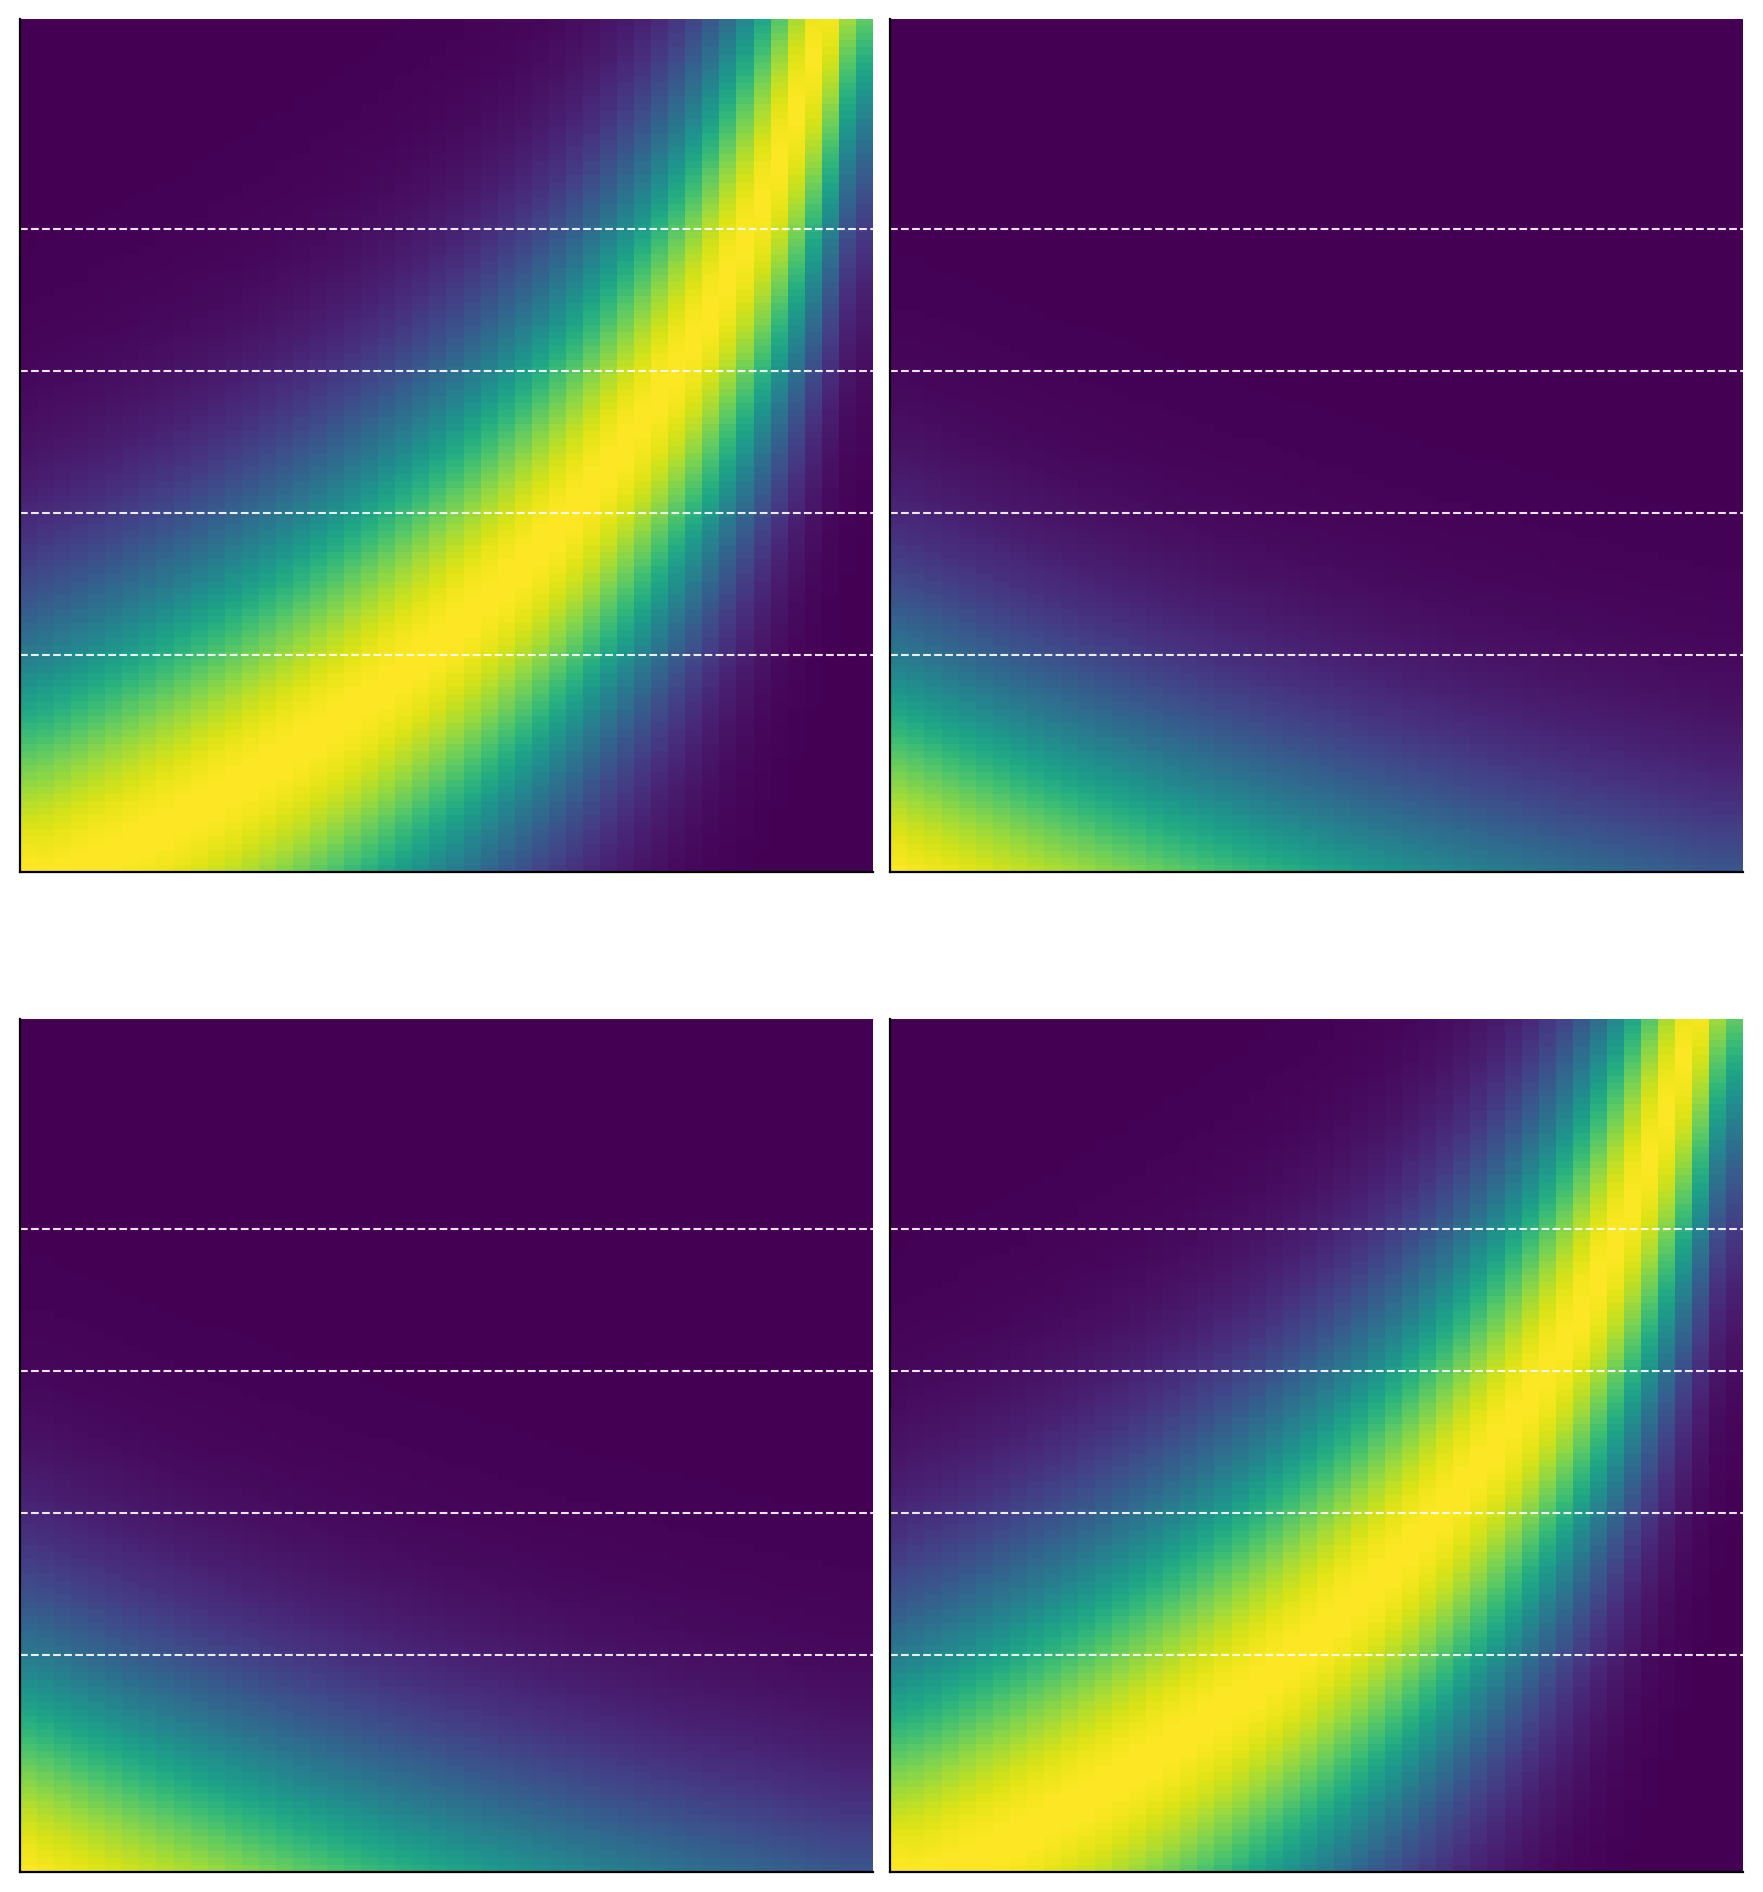

fig4_bump_dv_receptive_fields_peak_for_normalization: 0.8423423156851814
theta bounds: -0.91 0.91
saved_png /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4/fig4_bump_dv_receptive_fields_2x2rf.png
bump examples: [482, 502, 522, 542]
bump example theta: ['-0.45', '-0.15', '0.16', '0.47']


In [27]:
bump_example_global_indices = [482, 502, 522, 542]

bump_fig, bump_axes = plot_population_rf_figure(
    RF_B,
    bump_example_global_indices,
    curve_color=BUMP_COLOR,
    save_stem='fig4_bump_dv_receptive_fields',
    heatmap_y_tick_mode='bounds',
    draw_theta_lines=True,
)

print('bump examples:', bump_example_global_indices)
print('bump example theta:', [f'{selected_theta[i]:.2f}' for i in local_indices_from_global(bump_example_global_indices)])

## Notes

-  and  are available as notebook variables with shape .
- DV is  in .
- Post-decision samples are excluded for hit trials.
